# Fase 07 -- Serie pública adicional: visitas horarias de es.wikipedia (baseline rápido)

**¿Qué hace este cuaderno?** La consigna del TP final pide tres series. Además de ALB y store-service
(infraestructura de BodegaAI) se incorpora una serie **pública**: las visitas por hora de usuarios a Wikipedia en
español (API de Wikimedia, proyecto `es.wikipedia`, acceso `all-access`, agente `user`; datos bajo licencia CC0).
Comparte con las otras dos el mismo calendario (2.063 horas, del 2026-07-03 al 2026-09-26, sin huecos), el mismo
ciclo diario y las mismas ventanas de la fase 02 (validación de 48 h, test de 105 h), pero es tráfico externo, sin
el deploy/rollback del 17 al 22 de septiembre y con una autocorrelación semanal (rezago 168) mucho más alta.

**Alcance, dicho sin rodeos.** Es un *baseline de contraste*, no una réplica de las fases 02 a 06: seis modelos de
cinco familias con **hiperparámetros por defecto**, sin Deep Learning, sin AutoML, sin Chronos y sin búsqueda de
hiperparámetros. Ridge y LightGBM reciben como variable exógena la marca de intervención del despliegue, que vale 1 entre el 17 y el 22 de septiembre aunque esta serie no fue afectada; con la marca en cero, el MASE de prueba de Ridge pasa de 0,784 a 0,756 y el de LightGBM no cambia, sin alterar el orden de los modelos ni el de validación. La regla de selección es la misma que en el resto (menor MAE de validación) y los resultados de
ALB y store-service **no se recalculan**. Los datos se descargan con `experiments/00_download_wikipedia_es.py`.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsa_final import baselines as bl
from tsa_final import data as d
from tsa_final import evaluation as ev
from tsa_final import hybrid_models as hy
from tsa_final import ml_models as ml

RESULTS_DIR = Path.cwd().parent / "results"
FIGURES_DIR = Path.cwd().parent / "informe" / "figuras"
WIKI = "wikipedia_es"

FAMILY_COLORS = {
    "naive": "#999999",
    "classical": "#17becf",
    "SARIMA (TP1 refit)": "#1f77b4",
    "ML": "#2ca02c",
    "Prophet": "#9467bd",
}

Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


## 1. La serie y su estructura frente a las de BodegaAI

`load_clean("wikipedia_es")` no imputa intervención (la serie no fue afectada por el deploy; el registro la marca con
`"intervention": "no"`). La tabla compara la autocorrelación del logaritmo en los rezagos 24 (ciclo diario) y 168
(ciclo semanal). En Wikipedia la autocorrelación casi no decae entre 24 y 168 horas, mientras que en ALB baja
claramente; la segunda tabla muestra que la relación con las series de BodegaAI es de contexto (mismo ritmo diario),
no de dependencia: los cambios a 24 h prácticamente no están correlacionados.

wikipedia_es: 2063 horas, 2026-07-03 00:00:00+00:00 -> 2026-09-26 22:00:00+00:00
train 1794 h | val 48 h | test 105 h

               autocorr_lag24  autocorr_lag168
serie                                         
alb                     0.838            0.614
store_service           0.863            0.809
wikipedia_es            0.958            0.956

               corr_niveles  corr_cambios_24h
vs                                           
alb                   0.407            -0.011
store_service         0.493             0.012


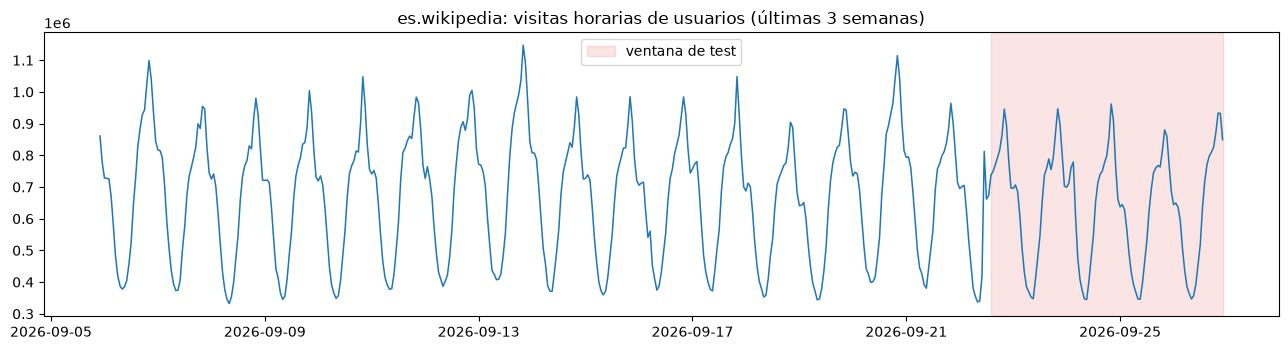

In [2]:
wiki = d.load_clean(WIKI)
wiki_train, wiki_val, wiki_test = ev.split(wiki)
print(f"{WIKI}: {len(wiki)} horas, {wiki.index[0]} -> {wiki.index[-1]}")
print(f"train {len(wiki_train)} h | val {len(wiki_val)} h | test {len(wiki_test)} h")

rows = []
for name in ["alb", "store_service", WIKI]:
    x = np.log(d.load_clean(name).astype(float))
    rows.append({"serie": name, "autocorr_lag24": x.autocorr(24), "autocorr_lag168": x.autocorr(168)})
structure = pd.DataFrame(rows).set_index("serie").round(3)
print()
print(structure.to_string())

rel = []
for name in ["alb", "store_service"]:
    other = d.load_clean(name).astype(float)
    joint = pd.concat([np.log(other).rename("x"), np.log(wiki.astype(float)).rename("w")], axis=1).dropna()
    rel.append({
        "vs": name,
        "corr_niveles": joint["x"].corr(joint["w"]),
        "corr_cambios_24h": joint["x"].diff(24).corr(joint["w"].diff(24)),
    })
print()
print(pd.DataFrame(rel).set_index("vs").round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 3.6))
recent = wiki.loc[wiki.index[-1] - pd.Timedelta(days=21):]
ax.plot(recent.index, recent.to_numpy(), color="#1f77b4", lw=1.1)
ax.axvspan(wiki_test.index[0], wiki_test.index[-1], color="#d62728", alpha=0.12, label="ventana de test")
ax.set_title("es.wikipedia: visitas horarias de usuarios (últimas 3 semanas)")
ax.legend()
fig.tight_layout()
plt.show()

## 2. Seis modelos rápidos con hiperparámetros por defecto

`seasonal_naive_m24` (naive), `holt_winters` (clásico), `SARIMA(1, 1, 1)x(1, 1, 1, 24)` (la especificación de ALB del
TP1, **no ajustada a esta serie**), `ridge` y `lightgbm` (recursivos con rezagos de hasta 336 h y calendario) y
`prophet_default`. Mismo protocolo de la fase 02: un ajuste sobre `train` para validar (48 h) y otro sobre
`train + val + tramo de intervención` para el test (105 h). MASE con m=24.

In [3]:
wiki_models = [
    ("seasonal_naive_m24", "naive", bl.NAIVE_MODELS["seasonal_naive_m24"]),
    ("holt_winters", "classical", bl.CLASSICAL_MODELS["holt_winters"]),
    ("SARIMA(1, 1, 1)x(1, 1, 1, 24)", "SARIMA (TP1 refit)", bl.make_sarima_fit((1, 1, 1), (1, 1, 1, 24))),
    ("ridge", "ML", ml.RECURSIVE_MODELS["ridge"]),
    ("lightgbm", "ML", ml.RECURSIVE_MODELS["lightgbm"]),
    ("prophet_default", "Prophet", hy.prophet_default_fit),
]

wiki_table = ev.ResultsTable()
for name, family, fit in wiki_models:
    ev.evaluate(fit, model=name, family=family, series_name=WIKI, series=wiki, table=wiki_table)

wiki_res = wiki_table.to_frame()
wiki_res.to_csv(RESULTS_DIR / "07_wikipedia.csv", index=False)

cols = ["model", "family", "MAE", "MAPE_%", "MASE", "fit_time_s"]
for split_name, label in [("val", "Validación (48 h)"), ("test", "Test (105 h)")]:
    print(f"\n{label}")
    print(wiki_res[wiki_res.split == split_name].sort_values("MAE")[cols].round(3).to_string(index=False))

23:59:10 - cmdstanpy - INFO - Chain [1] start processing


23:59:10 - cmdstanpy - INFO - Chain [1] done processing


23:59:10 - cmdstanpy - INFO - Chain [1] start processing


23:59:10 - cmdstanpy - INFO - Chain [1] done processing



Validación (48 h)
                        model             family       MAE  MAPE_%  MASE  fit_time_s
           seasonal_naive_m24              naive 21146.771   3.519 0.438       0.000
              prophet_default            Prophet 31597.995   4.748 0.655       0.175
                     lightgbm                 ML 35076.467   5.574 0.727       0.417
SARIMA(1, 1, 1)x(1, 1, 1, 24) SARIMA (TP1 refit) 49383.801   8.724 1.023       3.501
                 holt_winters          classical 55195.648   9.534 1.143       0.206
                        ridge                 ML 65234.874  10.562 1.351       0.091

Test (105 h)
                        model             family        MAE  MAPE_%  MASE  fit_time_s
                        ridge                 ML  37830.596   6.482 0.784       0.004
           seasonal_naive_m24              naive  44587.781   7.835 0.924       0.000
              prophet_default            Prophet  54035.336   8.398 1.119       0.124
                     lightgb

## 3. Selección, desacuerdo validación/test y pronóstico de 48 h

Misma regla que en el resto del proyecto: **el modelo seleccionado es el de menor MAE de validación**. Se reporta
además el mejor y el peor en test. La validación es una sola ventana de 48 h y el test una sola de 105 h: si los
rankings discrepan, se dice, no se elige por test. El pronóstico final reajusta el modelo seleccionado con toda la
historia disponible y proyecta 48 horas fuera de muestra.

23:59:10 - cmdstanpy - INFO - Chain [1] start processing


23:59:10 - cmdstanpy - INFO - Chain [1] done processing


Seleccionado por validación : seasonal_naive_m24 (MAE val 21,147)
Mejor en test               : ridge (MAE test 37,831)
Peor en test                : SARIMA(1, 1, 1)x(1, 1, 1, 24) (MAE test 121,297)
Correlación de Spearman entre rankings val y test (6 modelos): 0.09

Pronóstico final: 48 h desde 2026-09-26 23:00:00+00:00 hasta 2026-09-28 22:00:00+00:00


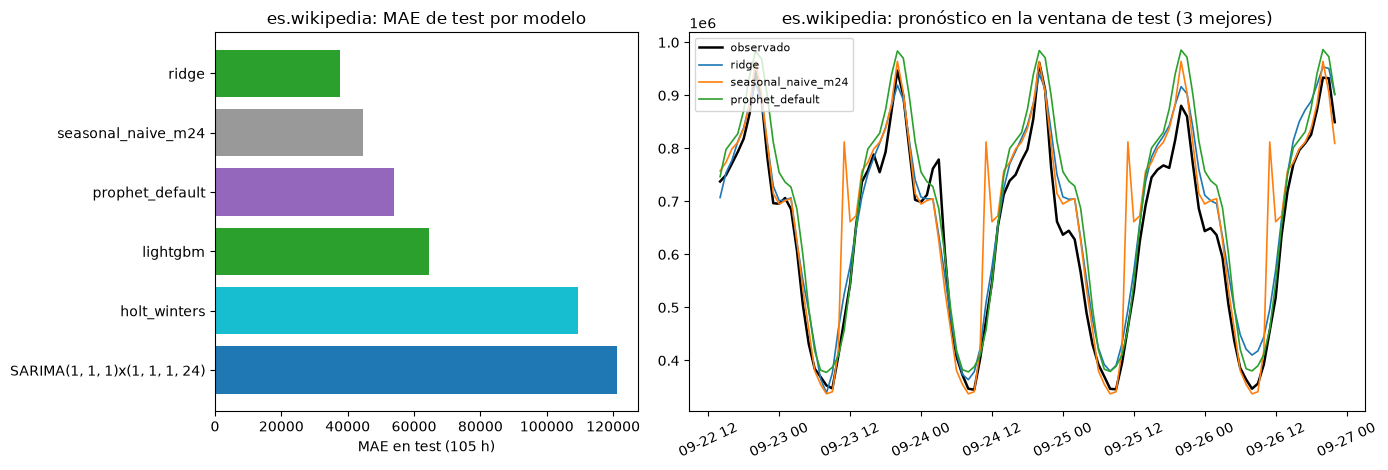

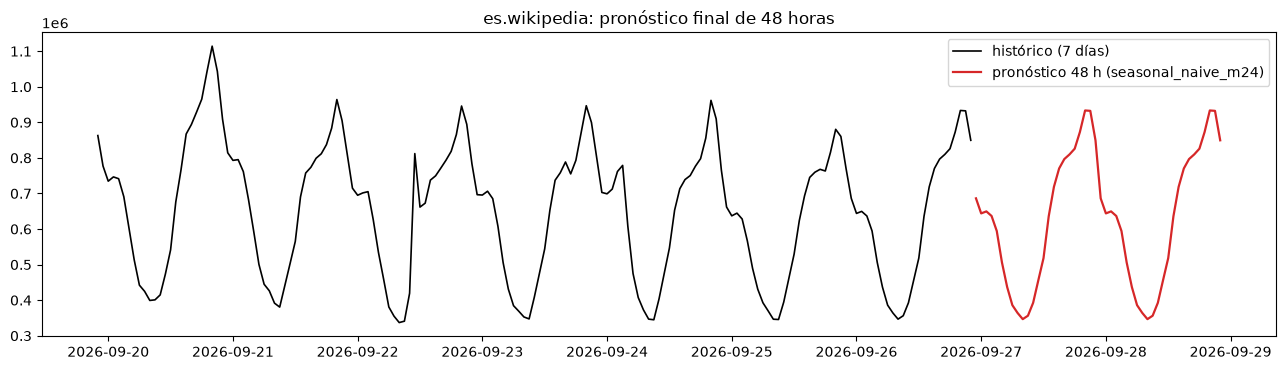

In [4]:
val_rank = wiki_res[wiki_res.split == "val"].sort_values("MAE").reset_index(drop=True)
test_rank = wiki_res[wiki_res.split == "test"].sort_values("MAE").reset_index(drop=True)
wiki_selected = val_rank.loc[0, "model"]
print(f"Seleccionado por validación : {wiki_selected} (MAE val {val_rank.loc[0, 'MAE']:,.0f})")
print(f"Mejor en test               : {test_rank.loc[0, 'model']} (MAE test {test_rank.loc[0, 'MAE']:,.0f})")
print(f"Peor en test                : {test_rank.iloc[-1]['model']} (MAE test {test_rank.iloc[-1]['MAE']:,.0f})")

merged = val_rank[["model", "MAE"]].merge(test_rank[["model", "MAE"]], on="model", suffixes=("_val", "_test"))
rho = merged["MAE_val"].rank().corr(merged["MAE_test"].rank())
print(f"Correlación de Spearman entre rankings val y test (6 modelos): {rho:.2f}")

fit_by_name = {name: fit for name, _, fit in wiki_models}
horizon = 48
future_index = pd.date_range(wiki.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h", tz="UTC")
wiki_forecast = pd.DataFrame({
    "timestamp": future_index,
    "series": WIKI,
    "role": "selected",
    "model": wiki_selected,
    "yhat": fit_by_name[wiki_selected](wiki)(horizon),
})
wiki_forecast.to_csv(RESULTS_DIR / "07_wikipedia_forecast.csv", index=False)
print(f"\nPronóstico final: {horizon} h desde {future_index[0]} hasta {future_index[-1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.6]})
order = test_rank.sort_values("MAE", ascending=False)
axes[0].barh(order["model"], order["MAE"], color=[FAMILY_COLORS.get(f, "#777777") for f in order["family"]])
axes[0].set_xlabel("MAE en test (105 h)")
axes[0].set_title("es.wikipedia: MAE de test por modelo")

test_fit_data = ev.train_and_val(wiki)
axes[1].plot(wiki_test.index, wiki_test.to_numpy(), color="black", lw=1.8, label="observado")
for name in list(test_rank["model"].head(3)):
    axes[1].plot(wiki_test.index, fit_by_name[name](test_fit_data)(len(wiki_test)), lw=1.2, label=name)
axes[1].set_title("es.wikipedia: pronóstico en la ventana de test (3 mejores)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_wikipedia_test.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(13, 3.8))
history = wiki.loc[wiki.index[-1] - pd.Timedelta(days=7):]
ax.plot(history.index, history.to_numpy(), color="black", lw=1.2, label="histórico (7 días)")
ax.plot(wiki_forecast["timestamp"], wiki_forecast["yhat"], color="#d62728", lw=1.6, label=f"pronóstico 48 h ({wiki_selected})")
ax.set_title("es.wikipedia: pronóstico final de 48 horas")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_wikipedia_forecast.png", dpi=150)
plt.show()

## Verificación de integridad

In [5]:
assert len(wiki) == 2063
assert wiki_res.shape[0] == len(wiki_models) * 2, "esperaba 6 modelos x 2 ventanas"
assert wiki_res[["MAE", "MASE"]].notna().all().all()
assert wiki_forecast.shape[0] == 48 and wiki_forecast["yhat"].notna().all()
assert wiki_forecast["timestamp"].iloc[0] == wiki.index[-1] + pd.Timedelta(hours=1)
print("Todas las verificaciones de integridad pasaron.")

Todas las verificaciones de integridad pasaron.
